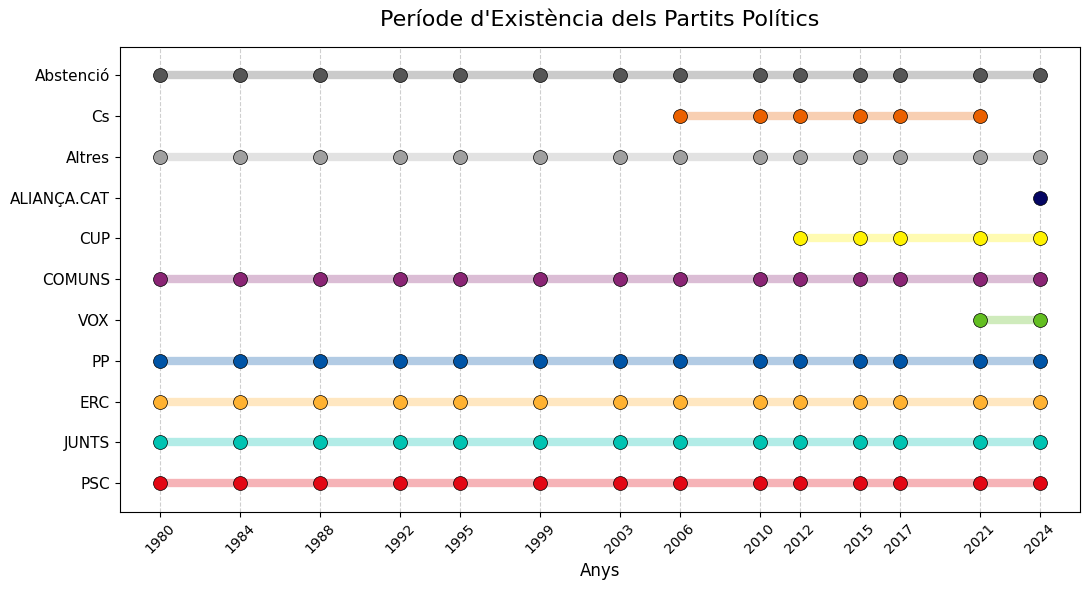

In [1]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("data.csv", index_col=0)

def plot_party_existence(df, filename="party_existence.png"):
    # Group parties/columns
    parties = df.columns
    years = df.index.to_numpy()
    
    # Specific colors for clear identity mapping
    colors = {
        'PSC': '#E30613', 'JUNTS': '#00C3B2', 'ERC': '#FFB232', 
        'PP': '#0054A6', 'VOX': '#63BE21', 'COMUNS': '#8A2574', 
        'CUP': '#FFF200', 'ALIANÇA.CAT': "#050663", 'Altres': '#A0A0A0', 
        'Cs': '#EB6100', 'Abstenció': '#555555'
    }

    fig, ax = plt.subplots(figsize=(11, 6))
    
    # We iterate over each party and map out bars for years they exist
    for idx, party in enumerate(parties):
        # Find the years where this party had a value greater than 0
        existing_years = years[df[party] > 0]
        
        if len(existing_years) > 0:
            # Plot a horizontal line/thin bar for continuous blocks or dots for scattered presence
            color = colors.get(party, '#333333')
            
            # Using a scatter/hlines combo to represent continuous segments
            ax.hlines(
                y=idx, 
                xmin=existing_years.min(), 
                xmax=existing_years.max(), 
                color=color, 
                linewidth=6, 
                alpha=0.3
            )
            # Draw markers on the exact years they run in elections
            ax.scatter(
                existing_years, 
                [idx] * len(existing_years), 
                color=color, 
                s=100, 
                zorder=3, 
                edgecolors='black', 
                linewidths=0.5
            )

    # Formatting axes
    ax.set_title(r"Període d'Existència dels Partits Polítics", fontsize=16, pad=15)
    ax.set_xlabel(r"Anys", fontsize=12)
    
    # Set the y-axis labels to the party names
    ax.set_yticks(range(len(parties)))
    ax.set_yticklabels([rf"{p}" for p in parties], fontsize=11)
    
    # Grid lines for years to follow the timeline easily
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Limits adjustments so nothing gets cut off
    ax.set_xlim(years.min() - 2, years.max() + 2)
    ax.set_ylim(-0.7, len(parties) - 0.3)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        
    plt.show()

# Run the function
plot_party_existence(df)